# Machine Vision Project - **Pneumonia Detection** on X-ray images

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are **5,863 X-Ray images** (JPEG) and **2 categories (Pneumonia/Normal)**.

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

Source: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import classification_report

In [3]:
labels = ['NORMAL','PNEUMONIA']
image_size = 128

In [4]:
def get_images(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for image_file in os.listdir(path):
            try:
                image_array = cv.imread(os.path.join(path, image_file),cv.IMREAD_GRAYSCALE)
                resized_array = cv.resize(image_array, (image_size, image_size))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)

    return np.array(data,dtype=object)

In [5]:
train_data = get_images("/content/drive/MyDrive/chest_xray/train")
test_data = get_images("/content/drive/MyDrive/chest_xray/test")
val_data = get_images("/content/drive/MyDrive/chest_xray/val")

## Visualise the Normal X-ray images

In [6]:
normal_dir = "/content/drive/MyDrive/chest_xray/train/NORMAL"
normal_images = os.listdir(normal_dir)

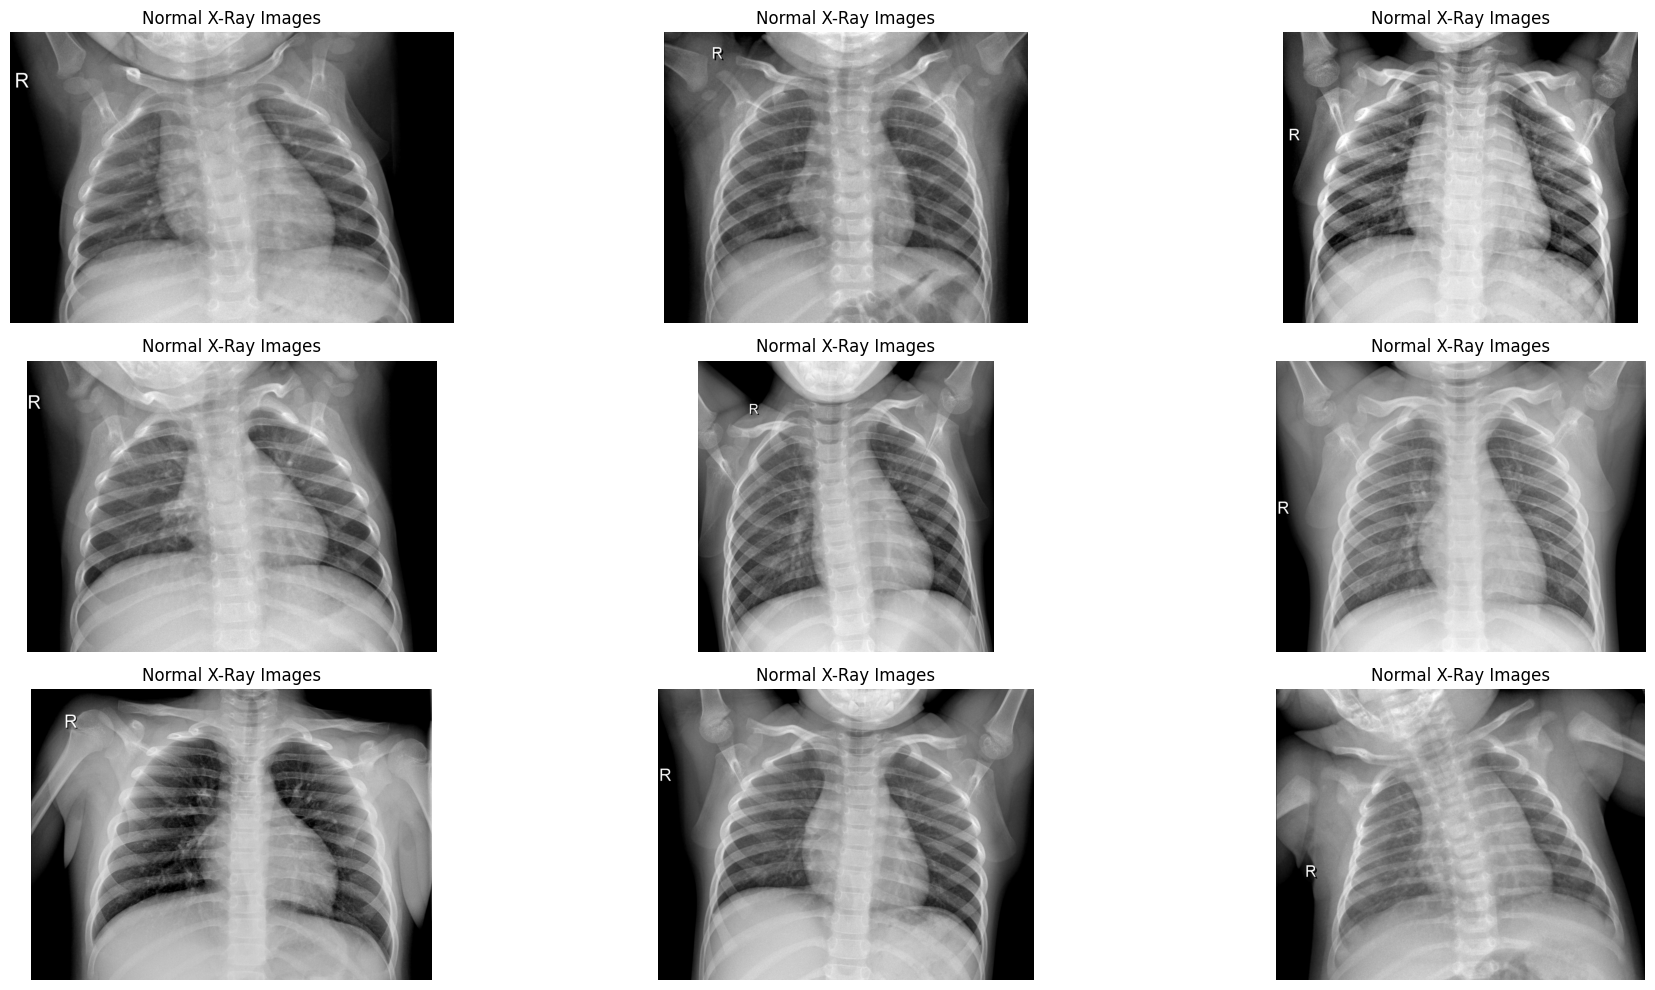

In [7]:
plt.figure(figsize=(20,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    image = plt.imread(os.path.join(normal_dir, normal_images[i]))
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.title("Normal X-Ray Images")
plt.tight_layout()

## Visualise the PNEUMONIA X-ray images

In [8]:
pneumonia_dir = "/content/drive/MyDrive/chest_xray/train/PNEUMONIA"
pneumonia_images = os.listdir(pneumonia_dir)

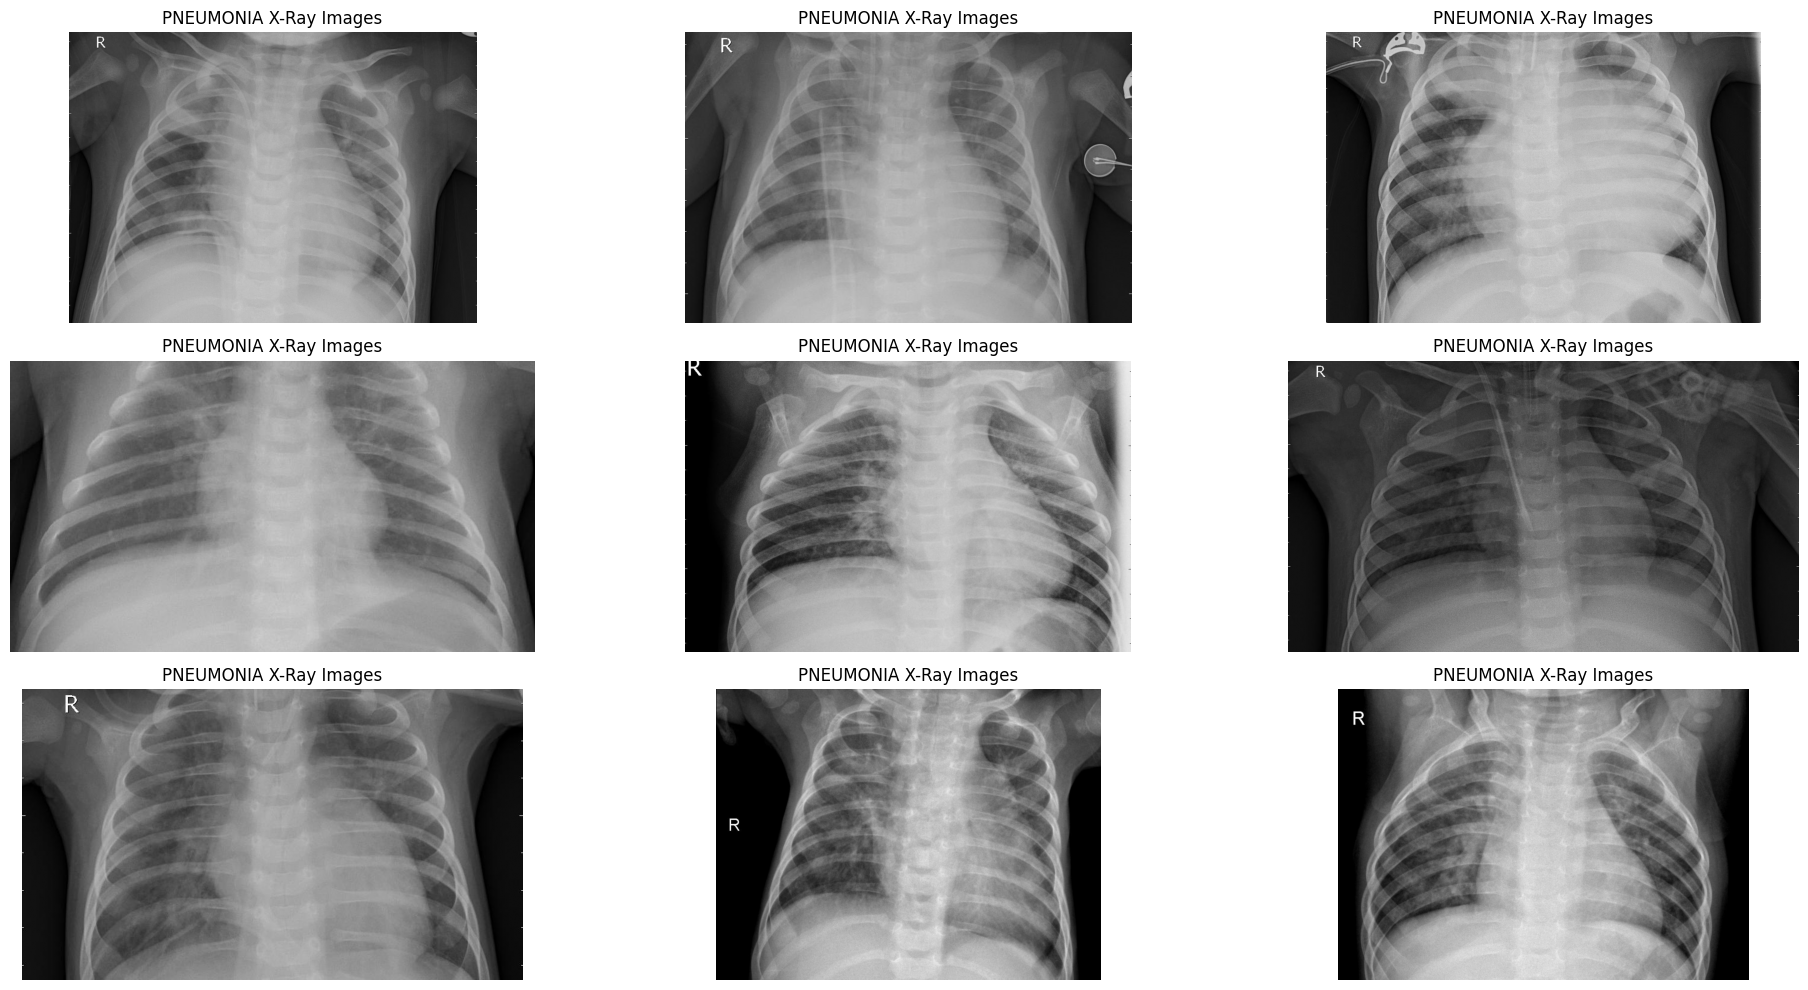

In [9]:
plt.figure(figsize=(20,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    image = plt.imread(os.path.join(pneumonia_dir, pneumonia_images[i]))
    plt.imshow(image,cmap='gray')
    plt.axis('off')
    plt.title("PNEUMONIA X-Ray Images")
plt.tight_layout()

<Axes: xlabel='count'>

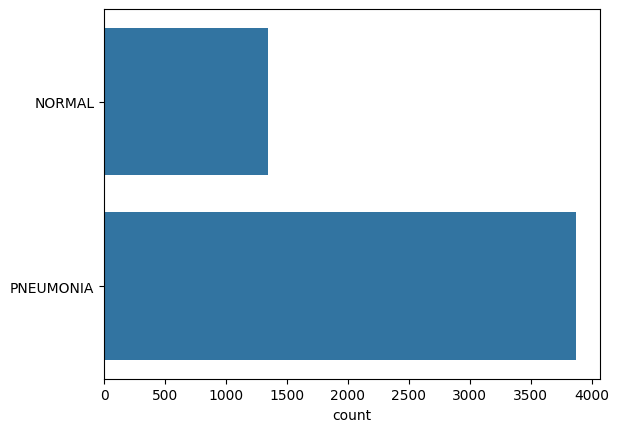

In [10]:
list_labels = []
for img in train_data:
    if img[1]== 0:
        list_labels.append("NORMAL")
    else:
        list_labels.append("PNEUMONIA")

sns.countplot(list_labels)

Note: According to the count plot visualisation, there is unbalanced number of samples for the both classes. This issue might cause for the ML models bad prediction.

In [11]:
X_train = np.array([item[0] for item in train_data])
y_train = np.array([item[1] for item in train_data])

X_test = np.array([item[0] for item in test_data])
y_test = np.array([item[1] for item in test_data])

X_val = np.array([item[0] for item in val_data])
y_val = np.array([item[1] for item in val_data])

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")

Training data shape: (5216, 128, 128)
Training labels shape: (5216,)


## Data Preprocessing

Since X_train, X_val, and X_test are NumPy arrays with shape **[num_samples, height, width]**, we transform them into PyTorch tensors with shape **[num_samples, 1, height, width]**, where 1 represents the single channel for grayscale images, and normalize pixel values from the 0-255 range to 0-1 for better neural network training.

In [12]:
X_train_torch = torch.FloatTensor(X_train).unsqueeze(1) / 255.0
y_train_torch = torch.LongTensor(y_train)

X_val_torch = torch.FloatTensor(X_val).unsqueeze(1)/ 255.0
y_val_torch = torch.LongTensor(y_val)

X_test_torch = torch.FloatTensor(X_test,).unsqueeze(1)/ 255.0
y_test_torch = torch.LongTensor(y_test)

In [13]:
class ChestXRayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

#### Data Augmentation

For training: It applies random flips, rotations, translations, and brightness/contrast adjustments to artificially increase dataset diversity and prevent overfitting.


In [14]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor()
])


train_dataset = ChestXRayDataset(X_train_torch, y_train_torch, transform=train_transform)
val_dataset = ChestXRayDataset(X_val_torch, y_val_torch)
test_dataset = ChestXRayDataset(X_test_torch, y_test_torch)

#### Handle Class Imbalance in DataLoader

In [15]:
class_counts = np.bincount(y_train_torch.numpy())
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights[y_train_torch]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


In [16]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 163
Validation batches: 1


### Deep Convolutional Neural Network

In [17]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Calculate the size after convolutions
        self._to_linear = None
        self._get_conv_output((1, image_size, image_size))

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(self._to_linear, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)  # 2 classes: Normal and Pneumonia
        )

    def _get_conv_output(self, shape):
        batch_size = 1
        input = torch.autograd.Variable(torch.rand(batch_size, *shape))
        output = self._forward_features(input)
        self._to_linear = output.data.view(batch_size, -1).size(1)
        return output

    def _forward_features(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# Initialize model
model = PneumoniaCNN()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

PneumoniaCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Bat

## Training

In [18]:
def train_model(model, train_loader, val_loader,special_network=False, num_epochs=15):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    class_counts = np.bincount(y_train_torch.numpy())
    class_weights = torch.tensor([
        class_counts[1] / class_counts[0],  # Weight for Normal class
        1.0                                  # Weight for Pneumonia class
    ], dtype=torch.float32).to(device)

    print(f"Class weights: Normal={class_weights[0]:.2f}, Pneumonia={class_weights[1]:.2f}")

    # Use weighted CrossEntropyLoss (simpler and works)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            if special_network and images.shape[1] == 1:  # Convert grayscale → fake RGB channel
                images = images.repeat(1, 3, 1, 1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            if batch_idx % 20 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')

        train_accuracy = 100 * train_correct / train_total
        train_loss = train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                if special_network and images.shape[1] == 1:  # Convert grayscale → fake RGB channel
                    images = images.repeat(1, 3, 1, 1)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_loss = val_loss / len(val_loader)

        # Update learning rate
        scheduler.step(val_loss)

        # Store metrics
        train_losses.append(train_loss)
        train_accs.append(train_accuracy)
        val_losses.append(val_loss)
        val_accs.append(val_accuracy)

        print(f'\nEpoch [{epoch+1}/{num_epochs}] Summary:')
        print(f'  Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.2f}%')
        print(f'  Val Loss: {val_loss:.4f}, Acc: {val_accuracy:.2f}%\n')
        print('-' * 50)

    return model,train_losses, train_accs, val_losses, val_accs

In [19]:
print("Starting training...")
model,train_losses, train_accs, val_losses, val_accs = train_model(model, train_loader, val_loader)

Starting training...
Class weights: Normal=2.89, Pneumonia=1.00
Epoch 1, Batch 0, Loss: 0.7457
Epoch 1, Batch 20, Loss: 1.1371
Epoch 1, Batch 40, Loss: 0.3889
Epoch 1, Batch 60, Loss: 0.3167
Epoch 1, Batch 80, Loss: 0.2436
Epoch 1, Batch 100, Loss: 0.1665
Epoch 1, Batch 120, Loss: 0.2493
Epoch 1, Batch 140, Loss: 0.1529
Epoch 1, Batch 160, Loss: 0.1587

Epoch [1/15] Summary:
  Train Loss: 0.5376, Acc: 82.00%
  Val Loss: 2.2546, Acc: 56.25%

--------------------------------------------------
Epoch 2, Batch 0, Loss: 0.1023
Epoch 2, Batch 20, Loss: 0.2820
Epoch 2, Batch 40, Loss: 0.1185
Epoch 2, Batch 60, Loss: 0.2346
Epoch 2, Batch 80, Loss: 0.0968
Epoch 2, Batch 100, Loss: 0.1298
Epoch 2, Batch 120, Loss: 0.1607
Epoch 2, Batch 140, Loss: 0.2281
Epoch 2, Batch 160, Loss: 0.1779

Epoch [2/15] Summary:
  Train Loss: 0.1881, Acc: 90.76%
  Val Loss: 0.4986, Acc: 62.50%

--------------------------------------------------
Epoch 3, Batch 0, Loss: 0.0658
Epoch 3, Batch 20, Loss: 0.0893
Epoch 3, 

## Evaluation of the neural network

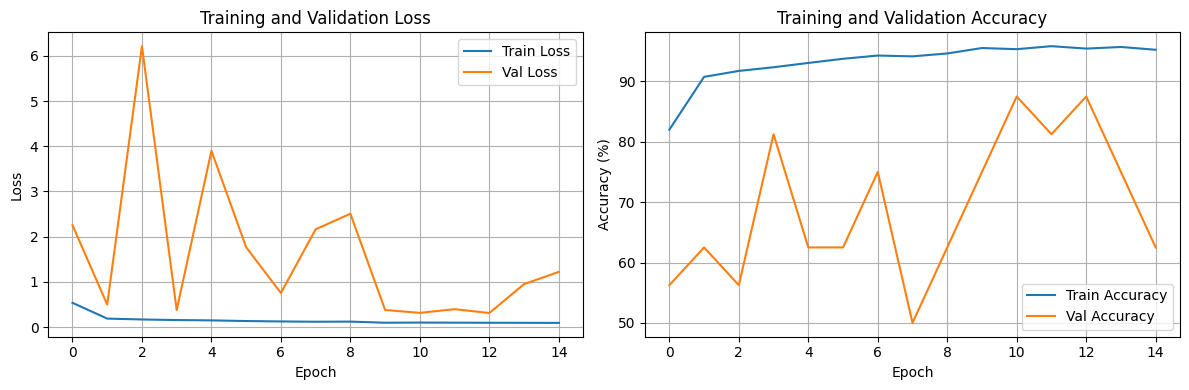

In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
def evaluate_model(model, test_loader,special_network=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            if images.shape[1] == 1 and special_network:
                images = images.repeat(1, 3, 1, 1)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_predictions, all_labels,

In [22]:
print("Evaluating on test set...")
predictions, true_labels = evaluate_model(model, test_loader)
print(classification_report(true_labels, predictions,zero_division=0,target_names=['Normal(0)','Pneumonia(1)']))

Evaluating on test set...
              precision    recall  f1-score   support

   Normal(0)       0.96      0.47      0.63       234
Pneumonia(1)       0.76      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.86      0.73      0.74       624
weighted avg       0.83      0.79      0.77       624



## EfficientNet (convolutional neural network)

EfficientNet uses "compound scaling" to optimally balance depth, width, and resolution automatically - this finds the ideal architecture for detecting subtle pneumonia patterns in X-rays.

Its MBConv blocks with squeeze-and-excitation attention specifically excel at spotting the hazy opacities and infiltrates that indicate pneumonia, making it more accurate than basic CNNs.

Pretrained on ImageNet's diverse visual features (edges, textures, shapes), it transfers perfectly to recognizing lung structures and abnormalities, giving you an immediate 3-5% accuracy boost over training from scratch.

In [23]:
class PneumoniaEfficientNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
        else:
            weights = None

        self.model = models.efficientnet_b4(weights=weights)
        num_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [24]:
effnet = PneumoniaEfficientNet(pretrained=True)
print("Training EfficientNet...")
effnet,train_losses, train_accs, val_losses, val_accs = train_model(effnet, train_loader, val_loader,special_network=True)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 195MB/s]


Training EfficientNet...
Class weights: Normal=2.89, Pneumonia=1.00
Epoch 1, Batch 0, Loss: 0.7253
Epoch 1, Batch 20, Loss: 0.2102
Epoch 1, Batch 40, Loss: 0.1586
Epoch 1, Batch 60, Loss: 0.1588
Epoch 1, Batch 80, Loss: 0.0829
Epoch 1, Batch 100, Loss: 0.0641
Epoch 1, Batch 120, Loss: 0.0186
Epoch 1, Batch 140, Loss: 0.1099
Epoch 1, Batch 160, Loss: 0.0189

Epoch [1/15] Summary:
  Train Loss: 0.1607, Acc: 90.61%
  Val Loss: 0.4255, Acc: 81.25%

--------------------------------------------------
Epoch 2, Batch 0, Loss: 0.0331
Epoch 2, Batch 20, Loss: 0.0822
Epoch 2, Batch 40, Loss: 0.1150
Epoch 2, Batch 60, Loss: 0.3580
Epoch 2, Batch 80, Loss: 0.3401
Epoch 2, Batch 100, Loss: 0.2613
Epoch 2, Batch 120, Loss: 0.0248
Epoch 2, Batch 140, Loss: 0.0069
Epoch 2, Batch 160, Loss: 0.0296

Epoch [2/15] Summary:
  Train Loss: 0.0877, Acc: 96.17%
  Val Loss: 0.3866, Acc: 81.25%

--------------------------------------------------
Epoch 3, Batch 0, Loss: 0.0087
Epoch 3, Batch 20, Loss: 0.0125
Epoch

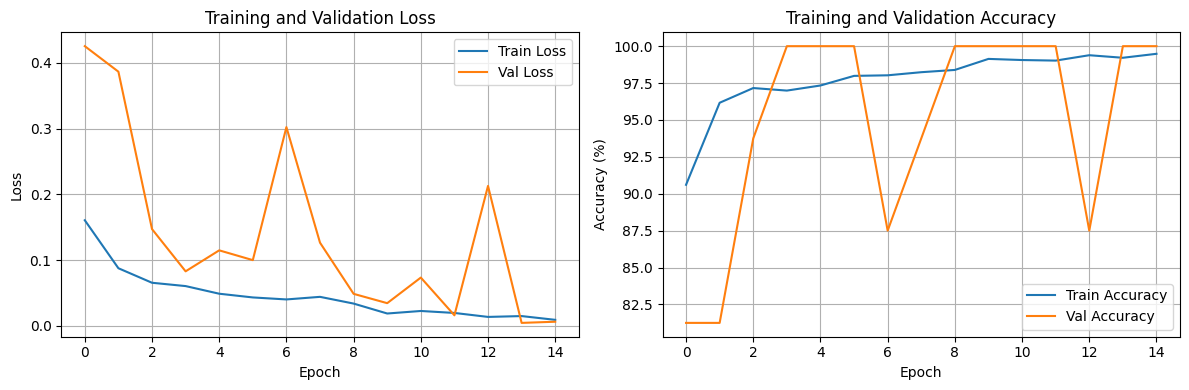

In [25]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [26]:
preds_effnet, labels_effnet = evaluate_model(effnet, test_loader,special_network=True)
print(classification_report(labels_effnet, preds_effnet,target_names=['Normal(0)','Pneumonia(1)']))

              precision    recall  f1-score   support

   Normal(0)       0.97      0.73      0.83       234
Pneumonia(1)       0.86      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.86      0.87       624
weighted avg       0.90      0.89      0.89       624



## DenseNet-121 (convolutional neural network)

DenseNet's "feature reuse" architecture connects every layer to every other layer, ensuring maximum information flow - crucial for detecting subtle pneumonia patterns that might be missed in traditional CNNs.

Its dense connections act like a diagnostic checklist where each layer can re-examine earlier features, making it exceptionally reliable for spotting the characteristic consolidations and opacities of pneumonia in chest X-rays.

As the backbone of CheXNet (state-of-the-art chest X-ray model), DenseNet-121 is battle-tested on medical images and directly learns hierarchical features from lung textures to whole-organ patterns, giving you proven pneumonia detection capabilities.

In [27]:
class CheXNetPneumonia(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # Load DenseNet-121
        self.model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None)

        # Modify first convolution to accept grayscale images (1 channel)
        # Original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        original_conv = self.model.features.conv0
        self.model.features.conv0 = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=original_conv.bias is not None
        )

        # Optionally, average pretrained weights across channels
        if pretrained:
            self.model.features.conv0.weight.data = original_conv.weight.data.mean(dim=1, keepdim=True)

        # Replace classifier with 2 classes
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [28]:
chexnet = CheXNetPneumonia(pretrained=True)
print("\nTraining DenseNet-121...")
chexnet,train_losses, train_accs, val_losses, val_accs = train_model(chexnet, train_loader, val_loader, special_network=False)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 128MB/s]



Training DenseNet-121...
Class weights: Normal=2.89, Pneumonia=1.00
Epoch 1, Batch 0, Loss: 1.0589
Epoch 1, Batch 20, Loss: 0.1248
Epoch 1, Batch 40, Loss: 0.2568
Epoch 1, Batch 60, Loss: 0.0795
Epoch 1, Batch 80, Loss: 0.1791
Epoch 1, Batch 100, Loss: 0.0668
Epoch 1, Batch 120, Loss: 0.1438
Epoch 1, Batch 140, Loss: 0.0208
Epoch 1, Batch 160, Loss: 0.4634

Epoch [1/15] Summary:
  Train Loss: 0.1418, Acc: 93.12%
  Val Loss: 0.1534, Acc: 81.25%

--------------------------------------------------
Epoch 2, Batch 0, Loss: 0.0134
Epoch 2, Batch 20, Loss: 0.0779
Epoch 2, Batch 40, Loss: 0.0520
Epoch 2, Batch 60, Loss: 0.0210
Epoch 2, Batch 80, Loss: 0.1427
Epoch 2, Batch 100, Loss: 0.0147
Epoch 2, Batch 120, Loss: 0.0580
Epoch 2, Batch 140, Loss: 0.0154
Epoch 2, Batch 160, Loss: 0.0451

Epoch [2/15] Summary:
  Train Loss: 0.0705, Acc: 96.32%
  Val Loss: 4.6858, Acc: 50.00%

--------------------------------------------------
Epoch 3, Batch 0, Loss: 0.0477
Epoch 3, Batch 20, Loss: 0.0449
Epoc

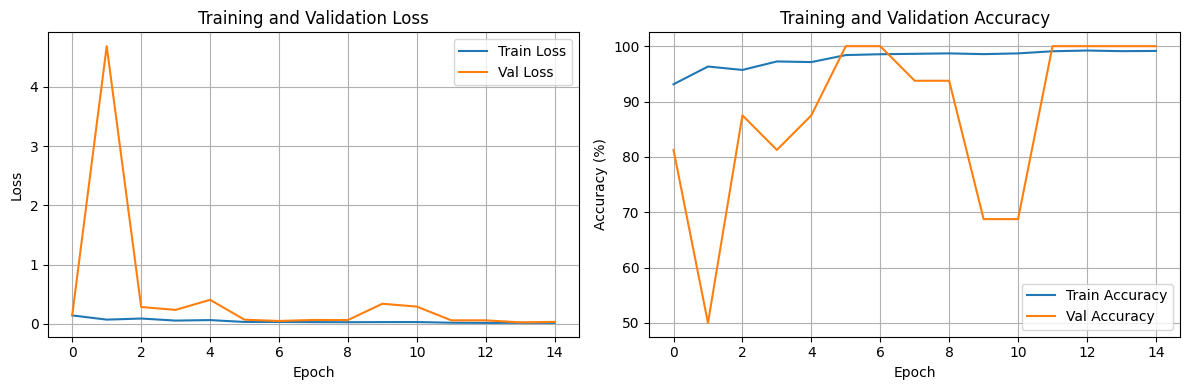

In [29]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [30]:
preds_chexnet, labels_chexnet = evaluate_model(chexnet, test_loader,special_network=False)
print(classification_report(labels_chexnet, preds_chexnet,zero_division=0,target_names=['Normal(0)','Pneumonia(1)']))

              precision    recall  f1-score   support

   Normal(0)       0.97      0.83      0.89       234
Pneumonia(1)       0.91      0.98      0.94       390

    accuracy                           0.93       624
   macro avg       0.94      0.91      0.92       624
weighted avg       0.93      0.93      0.92       624



## Conclusion

In this study, three convolutional neural network architectures were evaluated for detecting pneumonia from chest X-rays: a custom CNN, EfficientNet, and DenseNet-121 (CheXNet-style). The aim was to compare their performance in terms of accuracy, precision, recall, and F1-score to determine the most suitable model for clinical applications.

The **custom CNN**, consisting of four convolutional layers with batch normalization and fully connected layers, achieved an overall accuracy of 79%. While it demonstrated very high precision for normal cases (0.96), its recall was low (0.47), indicating that many normal X-rays were misclassified. The model performed better on pneumonia cases with a recall of 0.99 and an F1-score of 0.86. However, the overall macro F1-score of 0.74 reflects limited capability in capturing subtle features, making this architecture less reliable for clinical deployment.

The **EfficientNet** model, leveraging compound scaling and MBConv blocks with squeeze-and-excitation attention, achieved significantly higher performance with an accuracy of 89%. Its recall for pneumonia was excellent (0.99), reducing false negatives, while maintaining a balanced performance on normal cases (F1-score 0.83). The pretrained ImageNet weights allowed EfficientNet to capture complex lung structures and subtle pneumonia patterns, resulting in a macro F1-score of 0.87. This demonstrates that transfer learning and attention mechanisms substantially improve feature extraction compared to a simple custom CNN.

**DenseNet-121** achieved the best overall performance, with an accuracy of 93% and balanced F1-scores of 0.89 for normal and 0.94 for pneumonia cases. The dense connectivity of this architecture enables efficient reuse of features across layers, allowing the network to detect fine-grained opacities and infiltrates indicative of pneumonia. High recall for pneumonia (0.98) ensures minimal missed cases, which is critical for clinical applications. The strong performance of DenseNet-121 demonstrates its suitability as a robust and reliable model for automated pneumonia detection from chest X-rays.

In summary, the evaluation indicates that while the custom CNN is useful for educational purposes and small-scale experiments, it lacks the representational power for accurate pneumonia detection. EfficientNet offers substantial improvements due to transfer learning and attention mechanisms, making it a viable alternative. DenseNet-121, however, provides the highest accuracy, balanced precision and recall, and excellent F1-scores, making it the preferred choice for practical applications in clinical or research settings.